In [1]:
from itertools import combinations

def _is_connected(cells):
    cell_set = set(cells)
    start = next(iter(cell_set))
    visited = {start}
    stack = [start]
    while stack:
        r, c = stack.pop()
        for dr in (-1, 0, 1):
            for dc in (-1, 0, 1):
                if dr == 0 and dc == 0:
                    continue
                nb = (r + dr, c + dc)
                if nb in cell_set and nb not in visited:
                    visited.add(nb)
                    stack.append(nb)
    return len(visited) == len(cells)

def _normalize(cells):
    min_r = min(r for r, c in cells)
    min_c = min(c for r, c in cells)
    return frozenset((r - min_r, c - min_c) for r, c in cells)

def _get_placements(canonical):
    max_r = max(r for r, c in canonical)
    max_c = max(c for r, c in canonical)
    placements = []
    for dr in range(3 - max_r):
        for dc in range(3 - max_c):
            matrix = [[0] * 3 for _ in range(3)]
            for r, c in canonical:
                matrix[r + dr][c + dc] = 1
            placements.append(matrix)
    return placements

def get_clue_shapes():
    """Returns all unique connected clue shapes for a 3x3 grid (sizes 2-9).

    Each entry:
      'size'       - number of cells
      'canonical'  - frozenset of (row, col) with bounding box anchored at (0, 0)
      'placements' - list of 3x3 binary matrices, one per valid position on the grid
    """
    all_cells = [(r, c) for r in range(3) for c in range(3)]
    seen = set()
    shapes = []

    for size in range(2, 10):
        for combo in combinations(all_cells, size):
            cells = set(combo)
            if not _is_connected(cells):
                continue
            canonical = _normalize(cells)
            if canonical in seen:
                continue
            seen.add(canonical)
            shapes.append({
                'size': size,
                'canonical': canonical,
                'placements': _get_placements(canonical),
            })

    return shapes

In [2]:
shapes = get_clue_shapes()

from collections import Counter
count_by_size = Counter(s['size'] for s in shapes)
print(f"Total unique shapes: {len(shapes)}")
for size in sorted(count_by_size):
    total_placements = sum(len(s['placements']) for s in shapes if s['size'] == size)
    print(f"  size {size}: {count_by_size[size]:3d} shapes, {total_placements:4d} total placements")

Total unique shapes: 294
  size 2:   4 shapes,   20 total placements
  size 3:  20 shapes,   48 total placements
  size 4:  58 shapes,   85 total placements
  size 5:  90 shapes,  102 total placements
  size 6:  76 shapes,   78 total placements
  size 7:  36 shapes,   36 total placements
  size 8:   9 shapes,    9 total placements
  size 9:   1 shapes,    1 total placements


In [3]:
# Pretty-print a single shape and its placements
def print_shape(shape):
    canonical = sorted(shape['canonical'])
    max_r = max(r for r, c in canonical)
    max_c = max(c for r, c in canonical)
    grid = [['.' ] * (max_c + 1) for _ in range(max_r + 1)]
    for r, c in canonical:
        grid[r][c] = '#'
    print(f"Size {shape['size']} | {len(shape['placements'])} placements | canonical:")
    for row in grid:
        print('  ' + ' '.join(row))
    print()

# Show the first 3 shapes of each size
from itertools import groupby
for size, group in groupby(shapes, key=lambda s: s['size']):
    for s in list(group)[:3]:
        print_shape(s)

Size 2 | 6 placements | canonical:
  # #

Size 2 | 6 placements | canonical:
  #
  #

Size 2 | 4 placements | canonical:
  # .
  . #

Size 3 | 3 placements | canonical:
  # # #

Size 3 | 4 placements | canonical:
  # #
  # .

Size 3 | 4 placements | canonical:
  # #
  . #

Size 4 | 2 placements | canonical:
  # # #
  # . .

Size 4 | 2 placements | canonical:
  # # #
  . # .

Size 4 | 2 placements | canonical:
  # # #
  . . #

Size 5 | 2 placements | canonical:
  # # #
  # # .

Size 5 | 2 placements | canonical:
  # # #
  # . #

Size 5 | 1 placements | canonical:
  # # #
  # . .
  # . .

Size 6 | 2 placements | canonical:
  # # #
  # # #

Size 6 | 1 placements | canonical:
  # # #
  # # .
  # . .

Size 6 | 1 placements | canonical:
  # # #
  # # .
  . # .

Size 7 | 1 placements | canonical:
  # # #
  # # #
  # . .

Size 7 | 1 placements | canonical:
  # # #
  # # #
  . # .

Size 7 | 1 placements | canonical:
  # # #
  # # #
  . . #

Size 8 | 1 placements | canonical:
  # # #
  # # #
  #

In [4]:
from puzzle.generator import generate_puzzle                                                                                                                                                       
   
solution, clues = generate_puzzle()          # 'easy', 'medium' (default), or 'hard'  

In [5]:
clues

[Clue(reveals=(((0, 1), CellReveal(color=None, shape='square')), ((1, 1), CellReveal(color=None, shape='square')), ((1, 2), CellReveal(color=None, shape='triangle')), ((2, 2), CellReveal(color=None, shape='circle')))),
 Clue(reveals=(((0, 0), CellReveal(color='blue', shape=None)), ((0, 1), CellReveal(color='blue', shape='square')), ((0, 2), CellReveal(color=None, shape='circle')), ((1, 0), CellReveal(color='red', shape='triangle')))),
 Clue(reveals=(((0, 1), CellReveal(color='blue', shape='square')), ((0, 2), CellReveal(color='green', shape=None)), ((1, 1), CellReveal(color='red', shape=None)), ((2, 1), CellReveal(color='blue', shape='circle'))))]

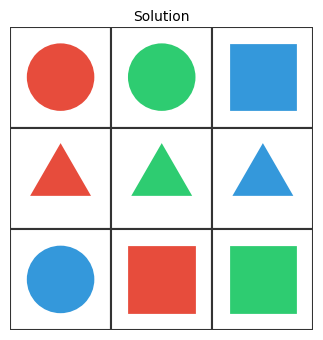

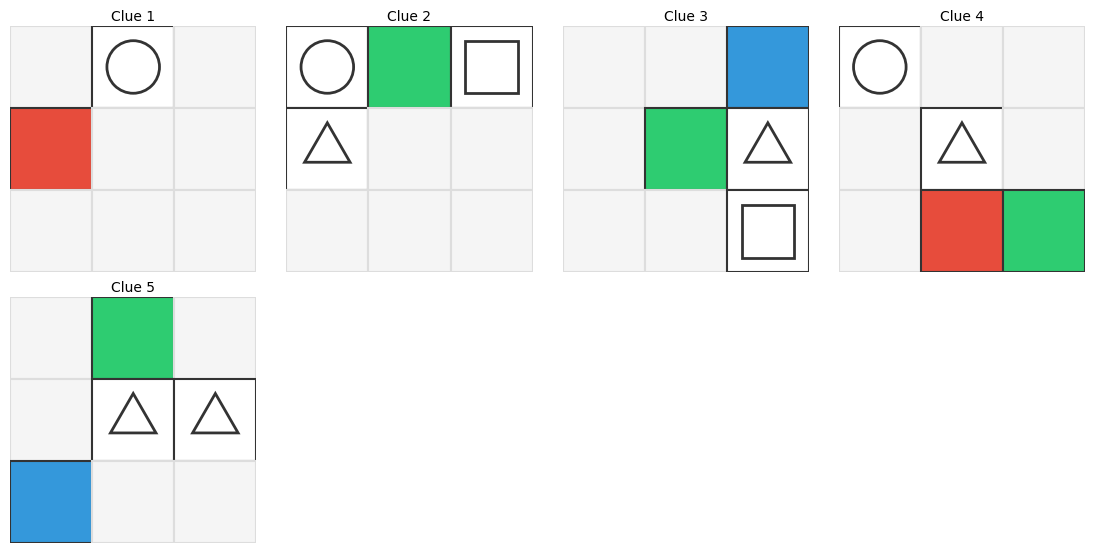

In [1]:
%matplotlib inline
from puzzle.generator import generate_puzzle
from puzzle.viz import show_solution, show_clues

solution, clues = generate_puzzle(difficulty='hard')

show_solution(solution)
show_clues(clues)

In [ ]:
9*8*7*6*5*4*3*2